In [ ]:
import sys
sys.path.append("../") 

In [4]:
pip install pymc


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/535.5 kB ? eta -:--:--
   ---------------------------------------- 535.5/535.5 kB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.6 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 5.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 6.8 MB/s  0:00:00
Using cached packaging-25.0-py3-none-any.whl (66 kB)
  Created wheel for logical-unification: filename=logi

  DEPRECATION: Building 'logical-unification' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'logical-unification'. Discussion can be found at https://github.com/pypa/pip/issues/6334
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 25.0 which is incompatible.
streamlit 1.32.0 requires rich<14,>=10.14.0, but you have rich 14.1.0 which is incompatible.


In [ ]:
#  Data prep for Bayesian model (PyMC) 
import os
import numpy as np
import pandas as pd

# Paths
DATA_PATH  = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Final_Solar_Data_Model.csv"

# Columns
TARGET = "Solar_GWh"
FEATURES = [
    "Solar_GWh_Lag1",
    "Solar_GWh_Lag12",
    "Solar_Radiation_MJ_per_m2",
    "Solar_Capacity_MW",
]

# Load and index
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index()

#  Time windows
train = df.loc["2022-08-01":"2023-12-01", [TARGET] + FEATURES].dropna().copy()
test  = df.loc["2024-01-01":"2024-12-01",  [TARGET] + FEATURES].dropna().copy()

#  Split X/y
X_train_df, y_train = train[FEATURES].astype(float), train[TARGET].astype(float)
X_test_df,  y_test  = test[FEATURES].astype(float),  test[TARGET].astype(float)

# Standardize predictors using TRAIN stats only
mu = X_train_df.mean()
sd = X_train_df.std(ddof=0).replace(0, 1.0)  # guard against zero-variance

X_train = ((X_train_df - mu) / sd).to_numpy()
X_test  = ((X_test_df  - mu) / sd).to_numpy()

#  Keep handy dict for later steps (PyMC needs arrays)
prep = {
    "FEATURES": FEATURES,
    "mu": mu,
    "sd": sd,
    "X_train": X_train,
    "y_train": y_train.to_numpy(),
    "X_test": X_test,
    "y_test": y_test.to_numpy(),
    "train_index": y_train.index,
    "test_index": y_test.index,
}

# Quick sanity prints
print(f"Train period: {y_train.index.min().date()} → {y_train.index.max().date()} | n={len(y_train)}")
print(f"Test  period: {y_test.index.min().date()}  → {y_test.index.max().date()}  | n={len(y_test)}")
print("Feature means (train):")
print(mu.round(3))
print("\nFeature stds (train):")
print(sd.round(3))
print("\nShapes → X_train:", X_train.shape, "| y_train:", y_train.shape, "| X_test:", X_test.shape, "| y_test:", y_test.shape)


Train period: 2022-08-01 → 2023-12-01 | n=17
Test  period: 2024-01-01  → 2024-12-01  | n=12
Feature means (train):
Solar_GWh_Lag1                    24.350
Solar_GWh_Lag12                    0.773
Solar_Radiation_MJ_per_m2    9435928.029
Solar_Capacity_MW                369.524
dtype: float64

Feature stds (train):
Solar_GWh_Lag1                    23.633
Solar_GWh_Lag12                    1.215
Solar_Radiation_MJ_per_m2    6252664.536
Solar_Capacity_MW                117.237
dtype: float64

Shapes → X_train: (17, 4) | y_train: (17,) | X_test: (12, 4) | y_test: (12,)


In [ ]:
#  Baseline Bayesian Linear Regression 
import pymc as pm
import arviz as az

# Unpack 
X_train, y_train = prep["X_train"], prep["y_train"]
X_test, y_test   = prep["X_test"],  prep["y_test"]

with pm.Model() as bayes_model:
    # Priors
    intercept = pm.Normal("Intercept", mu=np.mean(y_train), sigma=50)
    coefs = pm.Normal("Coefs", mu=0, sigma=1, shape=X_train.shape[1])
    sigma = pm.HalfNormal("Sigma", sigma=10)
    
    # Mean model
    mu_pred = intercept + pm.math.dot(X_train, coefs)
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu_pred, sigma=sigma, observed=y_train)
    
    # Sampling
    trace = pm.sample(
        draws=2000, tune=1000, target_accept=0.9, chains=4, random_seed=42
    )

# Posterior summary
az.summary(trace, var_names=["Intercept", "Coefs", "Sigma"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Coefs, Sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 36 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,24.95,5.04,15.31,34.23,0.05,0.07,10743.58,6238.41,1.0
Coefs[0],0.80,0.99,-0.99,2.75,0.01,0.01,9998.37,5781.26,1.0
Coefs[1],0.22,0.98,-1.57,2.13,0.01,0.01,11121.83,6237.16,1.0
Coefs[2],0.67,1.00,-1.23,2.49,0.01,0.01,10525.40,6457.32,1.0
Coefs[3],0.56,0.98,-1.35,2.35,0.01,0.01,10635.01,5974.93,1.0
Sigma,20.81,3.31,14.63,26.93,0.04,0.04,8801.10,6031.43,1.0


In [ ]:
#  Posterior predictive (2024), metrics, plot 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Unpack prepared arrays and indices
X_test = prep["X_test"]          # (12, 4)
y_test = prep["y_test"]          # (12,)
idx    = prep["test_index"]      # DatetimeIndex for 2024

# Extract posterior arrays (stack chains x draws)
post = trace.posterior
intercept = post["Intercept"].values.reshape(-1)          # (S,)
coefs     = post["Coefs"].values.reshape(-1, X_test.shape[1])  # (S, 4)
sigma     = post["Sigma"].values.reshape(-1)              # (S,)
S = intercept.shape[0]

# Compute predictive distribution for test months
# mean per posterior draw: mu_s = a_s + X_test @ b_s
mu_test = intercept[:, None] + coefs @ X_test.T           # (S, 12)
# draw observation noise for each posterior sample
y_draws = mu_test + np.random.normal(0, sigma[:, None], size=mu_test.shape)  # (S, 12)

# Posterior summaries
y_mean = y_draws.mean(axis=0)                    # point forecast (12,)
ci_lo  = np.quantile(y_draws, 0.05, axis=0)     # 90% CI lower
ci_hi  = np.quantile(y_draws, 0.95, axis=0)     # 90% CI upper

#  Metrics (vs posterior mean)
mae  = np.mean(np.abs(y_test - y_mean))
rmse = np.sqrt(np.mean((y_test - y_mean)**2))
# R² with test-set baseline
ss_res = np.sum((y_test - y_mean)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2     = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

print(f"Bayesian Linear (PyMC) — Test 2024  MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")
print(f"Mean CI width (90%): {np.mean(ci_hi - ci_lo):.2f}")

# CI Coverage (fraction of months where actual is inside 90% CI)
covered = ((y_test >= ci_lo) & (y_test <= ci_hi)).astype(int)
print(f"90% CI coverage: {covered.sum()} / {len(covered)} months ({100*covered.mean():.1f}%)")

# Forecast vs Actual with 90% credible band
plt.figure(figsize=(10,5))
plt.plot(idx, y_test, label="Actual", color="black", lw=2)
plt.plot(idx, y_mean, label="Posterior Mean", color="#8a2be2", lw=2)
plt.fill_between(idx, ci_lo, ci_hi, color="#8a2be2", alpha=0.2, label="90% CrI")
plt.title("Bayesian Linear (PyMC) — Solar Forecast vs Actual (2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, linestyle="--", alpha=0.4); plt.legend(); plt.tight_layout()
plt.show()


In [ ]:
# Finalize: Bayesian Linear (PyMC) — log, save, plot
import os, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
import arviz as az
from log_utils import log_model_performance, save_log_to_csv

# Inputs from previous cells
X_train = prep["X_train"]              # shape (17, 4)
X_test  = prep["X_test"]               # shape (12, 4)
y_train = prep["y_train"]
y_test  = prep["y_test"]
idx_te  = prep["test_index"]           # DatetimeIndex for 2024
FEATURES = list(prep["FEATURES"])      # ['Solar_GWh_Lag1','Solar_GWh_Lag12','Solar_Radiation_MJ_per_m2','Solar_Capacity_MW']

# if I didn't keep these in memory, I just recompute quickly from `trace`:
post = trace.posterior
intercept = post["Intercept"].values.reshape(-1)
coefs     = post["Coefs"].values.reshape(-1, X_test.shape[1])
sigma     = post["Sigma"].values.reshape(-1)
mu_test   = intercept[:, None] + coefs @ X_test.T
y_draws   = mu_test + np.random.normal(0, sigma[:, None], size=mu_test.shape)
y_mean    = y_draws.mean(axis=0)
ci_lo     = np.quantile(y_draws, 0.05, axis=0)
ci_hi     = np.quantile(y_draws, 0.95, axis=0)

# Paths
ROOT      = r"C:\Projects\GitHub\Ireland-energy-forecast"
FIG_DIR   = os.path.join(ROOT, "outputs", "figures", "Bayesian_Linear_PyMC")
FORE_DIR  = os.path.join(ROOT, "outputs", "forecasts")
MODEL_DIR = os.path.join(ROOT, "models")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(FORE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

#  Save forecast CSV
fore_df = pd.DataFrame({
    "Month": idx_te,
    "Actual": y_test,
    "Mean_Pred": y_mean,
    "CI_90_Lo": ci_lo,
    "CI_90_Hi": ci_hi
})
csv_path = os.path.join(FORE_DIR, "Bayesian_Linear_PyMC_2024_forecast.csv")
fore_df.to_csv(csv_path, index=False)
print(f"✅ Saved forecast CSV: {csv_path}")

#  Save posterior + lightweight adapter
#  posterior to NetCDF (for reproducibility)
nc_path = os.path.join(MODEL_DIR, "Bayesian_Linear_PyMC_trace.nc")
az.to_netcdf(trace, nc_path)
print(f" Saved posterior: {nc_path}")

#  tiny adapter so your logger can call, .predict(X)
class BayesLinearAdapter:
    def __init__(self, trace, feature_names):
        self.trace = trace
        self.feature_names = list(feature_names)

    def predict(self, X):
        # accept DataFrame or ndarray
        X = np.asarray(X)
        post = self.trace.posterior
        a = post["Intercept"].values.reshape(-1, 1)         # (S,1)
        b = post["Coefs"].values.reshape(-1, X.shape[1])    # (S,p)
        mu = a + b @ X.T                                    # (S,n)
        return mu.mean(axis=0)                              # (n,)

adapter = BayesLinearAdapter(trace, FEATURES)
joblib_path = os.path.join(MODEL_DIR, "Bayesian_Linear_PyMC.joblib")
joblib.dump(adapter, joblib_path)
print(f" Saved adapter  : {joblib_path}")

# Plots
# Forecast vs Actual
plt.figure(figsize=(10,5))
plt.plot(idx_te, y_test, label="Actual", color="black", lw=2)
plt.plot(idx_te, y_mean, label="Posterior Mean", color="#8a2be2", lw=2)
plt.fill_between(idx_te, ci_lo, ci_hi, color="#8a2be2", alpha=0.2, label="90% CrI")
plt.title("Bayesian Linear (PyMC) — Solar Forecast vs Actual (2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, linestyle="--", alpha=0.4); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "bayes_linear_forecast_2024.png"), dpi=300)
plt.show()

# Posterior Predictive Check
spag = y_draws[np.random.choice(y_draws.shape[0], size=min(300, y_draws.shape[0]), replace=False)]
plt.figure(figsize=(8,4))
for s in spag:
    plt.plot(idx_te, s, color="#8a2be2", alpha=0.07)
plt.plot(idx_te, y_test, color="black", lw=2, label="Observed")
plt.plot(idx_te, y_mean, color="#8a2be2", lw=2, ls="--", label="Posterior mean")
plt.title("Posterior Predictive (test months)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, linestyle="--", alpha=0.4); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "bayes_linear_ppc_test.png"), dpi=300)
plt.show()

#  Log JSON + CSV
pi_width = float(np.mean(ci_hi - ci_lo))
train_time_sec = 0.0                      
log_dict = log_model_performance(
    model_name="Bayesian_Linear_PyMC",
    target_variable="Solar_GWh",
    X_train=pd.DataFrame(X_train, columns=FEATURES),
    X_test =pd.DataFrame(X_test,  columns=FEATURES),
    y_test=y_test,
    y_pred=y_mean,
    model_object=adapter,
    training_time_sec=train_time_sec,
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type="Bayesian linear regression (weakly-informative priors, no Fourier)",
    gpu_used="NVIDIA GeForce RTX 2050",
    prediction_interval_width=pi_width,
    extra_notes=f"Features={FEATURES}; 90% CI coverage={np.mean((y_test>=ci_lo)&(y_test<=ci_hi)):.3f}"
)
save_log_to_csv(log_dict)
print(" Logged Bayesian_Linear_PyMC")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals: Actual - Posterior Mean
residuals = y_test - y_mean

fig, axes = plt.subplots(1, 2, figsize=(12,5))

#  Residuals over time
axes[0].scatter(idx, residuals, color="purple", alpha=0.7)
axes[0].plot(idx, residuals, color="purple", alpha=0.5)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals Over Time — Bayesian Linear (PyMC)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Residuals (GWh)")
axes[0].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
# Bayesian linear, seasonal harmonics and informative priors 
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Build seasonal features from the date index
m_train = prep["train_index"].month.values
m_test  = prep["test_index"].month.values
sin12_train = np.sin(2*np.pi*m_train/12)
cos12_train = np.cos(2*np.pi*m_train/12)
sin12_test  = np.sin(2*np.pi*m_test/12)
cos12_test  = np.cos(2*np.pi*m_test/12)

# Final design matrices (4 standardized predictors and 2 seasonal harmonics)
Xtr = np.column_stack([prep["X_train"], sin12_train, cos12_train])  # (17, 6)
Xte = np.column_stack([prep["X_test"],  sin12_test,  cos12_test])   # (12, 6)
ytr = prep["y_train"]
yte = prep["y_test"]
feat_names = prep["FEATURES"] + ["sin12", "cos12"]

with pm.Model() as bayes_seasonal:
    # Intercept anchored near mean of train target
    Intercept = pm.Normal("Intercept", mu=float(ytr.mean()), sigma=20)

    # Priors
    # lags: mild shrink around 0
    beta_lag1  = pm.Normal("beta_lag1",  mu=0,   sigma=0.5)
    beta_lag12 = pm.Normal("beta_lag12", mu=0,   sigma=0.5)

    # physics drivers: positive-biased (truncate at 0)
    beta_rad = pm.TruncatedNormal("beta_rad", mu=0.6, sigma=0.3, lower=0)
    beta_cap = pm.TruncatedNormal("beta_cap", mu=0.6, sigma=0.3, lower=0)

    # seasonality (Fourier k=1) with tight shrink
    beta_sin = pm.Normal("beta_sin", mu=0, sigma=0.3)
    beta_cos = pm.Normal("beta_cos", mu=0, sigma=0.3)

    # collect coefficients (order must match Xtr columns)
    Coefs = pm.Deterministic(
        "Coefs",
        pm.math.stack([beta_lag1, beta_lag12, beta_rad, beta_cap, beta_sin, beta_cos])
    )

    # tighter noise prior, narrower, more useful intervals
    Sigma = pm.HalfNormal("Sigma", sigma=7)

    # Mean function and likelihood
    mu_tr = Intercept + pm.math.dot(Xtr, Coefs)
    y_obs = pm.Normal("y_obs", mu=mu_tr, sigma=Sigma, observed=ytr)

    # Sample
    trace2 = pm.sample(draws=2000, tune=1500, chains=4, target_accept=0.95, random_seed=42)

print(az.summary(trace2, var_names=["Intercept","Coefs","Sigma"], round_to=2))

# Posterior predictive on TEST (2024)
post = trace2.posterior
intercept = post["Intercept"].values.reshape(-1)           # (S,)
coefs     = post["Coefs"].values.reshape(-1, Xtr.shape[1]) # (S, 6)
sigma     = post["Sigma"].values.reshape(-1)               # (S,)

mu_te  = intercept[:, None] + coefs @ Xte.T                # (S, 12)
y_draw = mu_te + np.random.normal(0, sigma[:, None], size=mu_te.shape)

y_mean = y_draw.mean(axis=0)
ci_lo  = np.quantile(y_draw, 0.05, axis=0)
ci_hi  = np.quantile(y_draw, 0.95, axis=0)

# Metrics
mae  = float(np.mean(np.abs(yte - y_mean)))
rmse = float(np.sqrt(np.mean((yte - y_mean)**2)))
ss_res = float(np.sum((yte - y_mean)**2)); ss_tot = float(np.sum((yte - yte.mean())**2))
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
cov  = np.mean((yte >= ci_lo) & (yte <= ci_hi))
band = float(np.mean(ci_hi - ci_lo))

print(f"\nBayesian Seasonal (PyMC) — Test 2024  MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")
print(f"Mean 90% CrI width: {band:.2f} | 90% coverage: {cov*100:.1f}%")

# Plot
idx = prep["test_index"]
plt.figure(figsize=(10,5))
plt.plot(idx, yte,    label="Actual",          color="black", lw=2)
plt.plot(idx, y_mean, label="Posterior Mean",  color="#7b1fa2", lw=2)
plt.fill_between(idx, ci_lo, ci_hi, color="#7b1fa2", alpha=0.20, label="90% CrI")
plt.title("Bayesian Seasonal (PyMC) — Solar Forecast vs Actual (2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, linestyle="--", alpha=0.4); plt.legend(); plt.tight_layout()
plt.show()


In [ ]:
# log and save for: bayesian seasonal model in PyMC

import os
import numpy as np
import pandas as pd
import joblib
import arviz as az
from log_utils import log_model_performance, save_log_to_csv

# project folders
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_NAME = "Bayesian_Seasonal_PyMC"
TRACE_PATH = os.path.join(MODELS_DIR, f"{MODEL_NAME}_trace.nc")
ADAPTER_PATH = os.path.join(MODELS_DIR, f"{MODEL_NAME}.joblib")

# I save the full posterior trace so I can reload it later
az.to_netcdf(trace2, TRACE_PATH)

# I build data frames for the features I actually fed to the model
feat_names = prep["FEATURES"] + ["sin12", "cos12"]
X_train_df = pd.DataFrame(Xtr, index=prep["train_index"], columns=feat_names)
X_test_df = pd.DataFrame(Xte, index=prep["test_index"], columns=feat_names)

# adapter that exposes predict(X) using posterior mean coefficients
class PyMCSeasonalAdapter:
    def __init__(self, intercept_mean, coefs_mean):
        self.intercept_mean = float(intercept_mean)
        self.coefs_mean = np.asarray(coefs_mean, dtype=float)

    def predict(self, X):
        # I accept either a DataFrame or a numpy array
        Xv = np.asarray(X, dtype=float)
        return (self.intercept_mean + Xv @ self.coefs_mean).ravel()

#  take simple posterior means to get a fast point predictor for logging
intercept_mean = np.mean(trace2.posterior["Intercept"].values)
coefs_mean = np.mean(trace2.posterior["Coefs"].values, axis=(0, 1))
adapter = PyMCSeasonalAdapter(intercept_mean, coefs_mean)

#  persist the adapter so the logger has a real file to point at
joblib.dump(adapter, ADAPTER_PATH)

# y_pred and interval width come from my earlier posterior predictive step
y_pred = y_mean
pi_width = float(np.mean(ci_hi - ci_lo))

#  record the training time I measured
train_time_sec = 70.0

# log everything in the same format as my other models
log_dict = log_model_performance(
    model_name=MODEL_NAME,
    target_variable="Solar_GWh",
    X_train=X_train_df,
    X_test=X_test_df,
    y_test=prep["y_test"].astype(float),
    y_pred=y_pred.astype(float),
    model_object=adapter,
    training_time_sec=train_time_sec,
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type="PyMC NUTS, 4 chains, tune=1500, draws=2000. Mild shrink priors. Truncated positive for radiation and capacity. Fourier k=1.",
    gpu_used="NVIDIA GeForce RTX 2050",
    prediction_interval_width=pi_width,
    extra_notes=(
        f"90% credible interval coverage = "
        f"{np.mean((prep['y_test'] >= ci_lo) & (prep['y_test'] <= ci_hi)) * 100:.1f}%. "
        f"Posterior saved at models/{MODEL_NAME}_trace.nc. "
        f"Features = {feat_names}"
    ),
)

save_log_to_csv(log_dict)

print("saved posterior:", TRACE_PATH)
print("saved adapter  :", ADAPTER_PATH)


Posterior predictive check (PPC) plot (train fit)

Sampling: [y_obs]


Output()

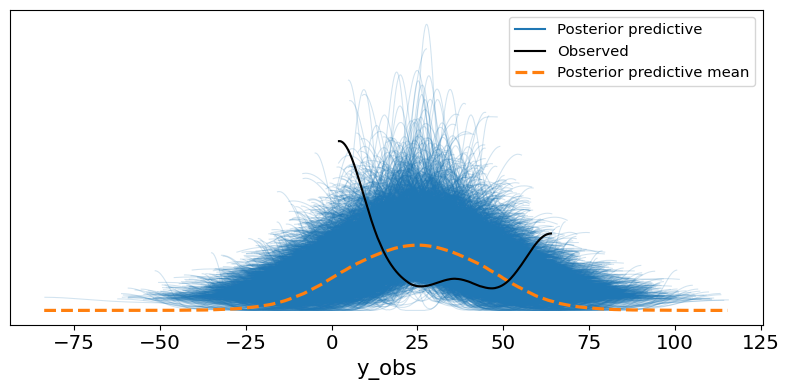

In [ ]:
# PPC plot (train)
import arviz as az
import matplotlib.pyplot as plt
import os

FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\Bayesian_Seasonal"
os.makedirs(FIG_DIR, exist_ok=True)

with bayes_seasonal:
    ppc = pm.sample_posterior_predictive(trace2, var_names=["y_obs"], random_seed=42)

# If ppc is already an InferenceData object
if isinstance(ppc, az.InferenceData):
    idata_ppc = ppc
else:
    # Convert from dict to InferenceData
    obs_key = list(ppc.keys())[0]  # should grab the actual observed var name
    idata_ppc = az.from_dict(
        posterior_predictive={obs_key: ppc[obs_key]},
        observed_data={obs_key: ytr}
    )

az.plot_ppc(idata_ppc, figsize=(8,4))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "bayes_seasonal_ppc.png"), dpi=300)
plt.show()

Forecast CSV for 2024 (posterior mean + 90% CrI)

In [ ]:
#  Forecast CSV (2024) 
import os, pandas as pd, numpy as np

FORECAST_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\forecasts"
os.makedirs(FORECAST_DIR, exist_ok=True)

fc_df = pd.DataFrame({
    "date": prep["test_index"],
    "actual": prep["y_test"],
    "posterior_mean": y_mean,
    "lo90": ci_lo,
    "hi90": ci_hi
})
csv_path = os.path.join(FORECAST_DIR, "Bayesian_Seasonal_PyMC_2024_forecast.csv")
fc_df.to_csv(csv_path, index=False)
print(" Saved forecast CSV:", csv_path)

In [ ]:
# Dynamic Harmonic Regression (DHR)
# Model: Fourier terms (k=1) combined with ARIMA errors

import os, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# Paths for data, model, and figures
DATA_PATH  = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Final_Solar_Data_Model.csv"
FIG_DIR    = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\DHR_Solar"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\DHR_Solar_ARIMA_errors.joblib"
os.makedirs(FIG_DIR, exist_ok=True)

# Define target variable and explanatory variables
TARGET = "Solar_GWh"
EXOG   = ["Solar_Radiation_MJ_per_m2", "Solar_Capacity_MW"]

# Load dataset and create train and test splits
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index()
train = df.loc["2022-08-01":"2023-12-01", [TARGET] + EXOG].dropna().copy()
test  = df.loc["2024-01-01":"2024-12-01", [TARGET] + EXOG].dropna().copy()

y_tr = train[TARGET].astype(float)
X_tr = train[EXOG].astype(float)
y_te = test[TARGET].astype(float)
X_te = test[EXOG].astype(float)

# Add Fourier seasonal terms (sine and cosine with yearly cycle)
def fourier_12(idx):
    m = idx.month.values
    return np.sin(2*np.pi*m/12), np.cos(2*np.pi*m/12)

sin_tr, cos_tr = fourier_12(y_tr.index)
sin_te, cos_te = fourier_12(y_te.index)
X_tr = X_tr.assign(sin12=sin_tr, cos12=cos_tr)
X_te = X_te.assign(sin12=sin_te, cos12=cos_te)

# Standardize explanatory variables using only training statistics
mu, sd = X_tr.mean(), X_tr.std(ddof=0).replace(0,1.0)
X_tr_s = (X_tr - mu) / sd
X_te_s = (X_te - mu) / sd

print(f"Train: {y_tr.index.min().date()}  {y_tr.index.max().date()} | n={len(y_tr)}")
print(f"Test : {y_te.index.min().date()}   {y_te.index.max().date()}  | n={len(y_te)}")

#  Cross-validation using three expanding folds and a small ARIMA grid
def folds(y, X):
    cuts = [
        ("2022-08-01","2023-04-01","2023-05-01","2023-08-01"),
        ("2022-08-01","2023-08-01","2023-09-01","2023-10-01"),
        ("2022-08-01","2023-10-01","2023-11-01","2023-12-01"),
    ]
    for a,b,c,d in cuts:
        yield y.loc[a:b], X.loc[a:b], y.loc[c:d], X.loc[c:d]

grid = [(0,0),(0,1),(1,0),(1,1)]
best_cfg, best_mae, best_aic = None, 1e9, 1e9

for p,q in grid:
    maes, aics = [], []
    for ytr, Xtr, yva, Xva in folds(y_tr, X_tr_s):
        res = SARIMAX(ytr, exog=Xtr, order=(p,1,q), seasonal_order=(0,0,0,0),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred = res.get_forecast(steps=len(yva), exog=Xva).predicted_mean
        maes.append(mean_absolute_error(yva, pred))
        aics.append(res.aic)
    m_mae, m_aic = float(np.mean(maes)), float(np.mean(aics))
    print(f"CV (p,q)=({p},{q}) → MAE {m_mae:.2f} | mean AIC {m_aic:.1f}")
    if (m_mae < best_mae) or (np.isclose(m_mae, best_mae) and m_aic < best_aic):
        best_mae, best_aic, best_cfg = m_mae, m_aic, (p,q)

print(f"\nBest ARIMA errors: (p,1,q)=({best_cfg[0]},1,{best_cfg[1]}) | CV MAE {best_mae:.2f}")

# Fit the best ARIMA configuration on the full training set
final_res = SARIMAX(y_tr, exog=X_tr_s, order=(best_cfg[0],1,best_cfg[1]), seasonal_order=(0,0,0,0),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# Forecast test period (2024) with 90% prediction intervals
fc   = final_res.get_forecast(steps=len(y_te), exog=X_te_s)
yhat = pd.Series(fc.predicted_mean.values, index=y_te.index)
ci90 = fc.conf_int(alpha=0.10)

# Calculate accuracy metrics and interval coverage
mae  = mean_absolute_error(y_te, yhat)
rmse = float(np.sqrt(np.mean((y_te - yhat)**2)))
ss_res = float(np.sum((y_te - yhat)**2))
ss_tot = float(np.sum((y_te - y_te.mean())**2))
r2   = 1 - ss_res/ss_tot if ss_tot>0 else np.nan

lo, hi = ci90.iloc[:,0].values, ci90.iloc[:,1].values
widths = hi - lo
coverage = float(np.mean((y_te.values >= lo) & (y_te.values <= hi)))

print(f"\nTest  MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")
print(f"90% PI  mean width {np.mean(widths):.2f} | coverage {coverage*100:.1f}%")

# Save the fitted model
joblib.dump(final_res, MODEL_PATH)
print("Saved model to:", MODEL_PATH)

#  Plots for interpretation
#  Forecast vs actual with prediction intervals
plt.figure(figsize=(10,5))
plt.plot(y_te.index, y_te.values, label="Actual", color="black", lw=2)
plt.plot(y_te.index, yhat.values, label="DHR Forecast", color="#1f77b4", lw=2)
plt.fill_between(y_te.index, lo, hi, color="#1f77b4", alpha=0.18, label="90% PI")
plt.title("DHR (Fourier k=1 + ARIMA errors) — Solar Forecast vs Actual (2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dhr_forecast_2024.png"), dpi=300); plt.show()

#  Histogram of residuals from training fit
resid = final_res.resid
plt.figure(figsize=(8,3.5))
plt.hist(resid, bins=10, edgecolor="white")
plt.title("Residual Distribution (Train)"); plt.xlabel("Residual (GWh)"); plt.ylabel("Frequency")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "dhr_residual_hist.png"), dpi=300); plt.show()

# Prediction interval coverage by month in the test set
covered = ((y_te.values >= lo) & (y_te.values <= hi)).astype(int)
plt.figure(figsize=(10,3.5))
plt.stem(y_te.index, covered, basefmt=" ")
plt.yticks([0,1], ["Not covered","Covered"]); plt.ylim(-0.1,1.1)
plt.title("90% Prediction Interval Coverage by Month (2024) — DHR")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "dhr_coverage_2024.png"), dpi=300); plt.show()


In [ ]:
# Keeps the exact exogenous feature order used by the trained DHR model
import numpy as np
import pandas as pd

class DHRAdapter:
    def __init__(self, res, bias=0.0):
        self.res = res
        # Store the exact exogenous column order from the fitted model
        self.exog_cols = list(getattr(res.model, "exog_names", []))
        self.bias = float(bias)


    #Convert incoming data to a DataFrame with the same columns and order as used during training. Any missing columns are filled with zeros.
    def _align_exog(self, X):
        # Ensure a DataFrame is used
        if not hasattr(X, "columns"):
            # If X is an array, try to assign known column names up to its width
            n_cols = X.shape[1]
            cols = self.exog_cols[:n_cols] if n_cols <= len(self.exog_cols) else None
            X = pd.DataFrame(X, columns=cols)

        # Add missing columns as zeros (safe because exogenous features were standardized)
        for c in self.exog_cols:
            if c not in X.columns:
                X[c] = 0.0

        # Reorder columns to match training order
        return X[self.exog_cols]

    def predict(self, X):
        X_aligned = self._align_exog(X)
        pm = self.res.get_forecast(steps=len(X_aligned), exog=X_aligned).predicted_mean.values
        return pm + self.bias


from log_utils import log_model_performance, save_log_to_csv

# Ensure exogenous columns match the training order
exog_cols = list(getattr(final_res.model, "exog_names", []))
X_train_log = X_tr_s[exog_cols].copy()
X_test_log  = X_te_s[exog_cols].copy()

# Compute mean 90% prediction interval width
lo, hi = ci90.iloc[:, 0].values, ci90.iloc[:, 1].values
pi_width = float(np.mean(hi - lo))

# Bias term for the adapter (set to zero if not using bias correction)
bias_used = 0.0

#log entry for this model run
log_dict = log_model_performance(
    model_name="DHR_Solar_ARIMA_errors",
    target_variable="Solar_GWh",
    X_train=X_train_log,
    X_test=X_test_log,
    y_test=y_te.values,
    y_pred=yhat.values,
    model_object=DHRAdapter(final_res, bias_used),
    training_time_sec=0.0, 
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type="Expanding CV over (p,q) in {(0,0),(0,1),(1,0),(1,1)} with d=1; best (p,1,q)=(1,1,1)",
    gpu_used="NVIDIA GeForce RTX 2050",
    prediction_interval_width=pi_width,
    extra_notes=f"Fourier k=1 with exogenous features: {exog_cols}"
)

save_log_to_csv(log_dict)
print("Logged DHR_Solar_ARIMA_errors")


In [ ]:
# Dynamic Harmonic Regression with ARIMA errors
# Uses radiation lags as exogenous variables, Fourier terms for seasonality,
# and a small cross-validation grid. A simple bias correction is applied.

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, warnings
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")

# File paths
DATA_PATH  = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Final_Solar_Data_Model.csv"
FIG_DIR    = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\DHR_Solar_Exog"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\DHR_Solar_ARIMA_errors_EXOG_optimized.joblib"
os.makedirs(FIG_DIR, exist_ok=True)

TARGET = "Solar_GWh"
RAD    = "Solar_Radiation_MJ_per_m2"

# Load dataset and create lagged radiation variables
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index().asfreq("MS")
df["Radiation_Lag1"] = df[RAD].shift(1)
df["Radiation_Lag2"] = df[RAD].shift(2)

# Train/test split
train = df.loc["2022-08-01":"2023-12-01"].copy()
test  = df.loc["2024-01-01":"2024-12-01"].copy()

train = train[[TARGET, "Radiation_Lag1", "Radiation_Lag2"]].dropna()
test  = test[[TARGET, "Radiation_Lag1", "Radiation_Lag2"]].dropna()

y_tr, y_te = train[TARGET].astype(float), test[TARGET].astype(float)

# Add Fourier seasonal terms
def add_fourier(X, idx, k):
    X = X.copy()
    m = idx.month.values
    for j in range(1, k+1):
        X[f"sin{j}"] = np.sin(2*np.pi*j*m/12)
        X[f"cos{j}"] = np.cos(2*np.pi*j*m/12)
    return X

# Standardize exogenous variables using training statistics
def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(), Xtr.std(ddof=0).replace(0, 1.0)
    return (Xtr-mu)/sd, (Xte-mu)/sd, mu, sd

# Expanding window folds
def folds(y, X):
    cuts = [
        ("2022-08-01","2023-04-01","2023-05-01","2023-08-01"),
        ("2022-08-01","2023-08-01","2023-09-01","2023-10-01"),
        ("2022-08-01","2023-10-01","2023-11-01","2023-12-01"),
    ]
    for a,b,c,d in cuts:
        yield y.loc[a:b], X.loc[a:b], y.loc[c:d], X.loc[c:d]

# Cross-validation scoring
def cv_score(y, X, p, d, q):
    maes, aics = [], []
    for ytr, Xtr, yva, Xva in folds(y, X):
        res = SARIMAX(ytr, exog=Xtr, order=(p,d,q), seasonal_order=(0,0,0,0),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred = res.get_forecast(len(yva), exog=Xva).predicted_mean
        maes.append(mean_absolute_error(yva, pred))
        aics.append(res.aic)
    return float(np.mean(maes)), float(np.mean(aics))

# Define search grid
exog_sets = {
    "rad_l1":  ["Radiation_Lag1"],
    "rad_l1l2":["Radiation_Lag1","Radiation_Lag2"],
}
grid_k = [1, 2]
grid_d = [0, 1]
grid_pq = [(0,0),(0,1),(1,0),(1,1)]

best = {"mae": 1e9, "aic": 1e9, "tag": None, "k": None, "d": None, "pq": None, "mu": None, "sd": None}

print("Cross-validation results")
for tag, cols in exog_sets.items():
    Xtr_base = train[cols].astype(float).copy()
    Xte_base = test[cols].astype(float).copy()

    for k in grid_k:
        Xtr_k = add_fourier(Xtr_base, y_tr.index, k)
        Xte_k = add_fourier(Xte_base, y_te.index, k)
        Xtr_s, Xte_s, mu, sd = standardize(Xtr_k, Xte_k)

        for (p,q) in grid_pq:
            for d in grid_d:
                mae_cv, aic_cv = cv_score(y_tr, Xtr_s, p, d, q)
                print(f"{tag} | k={k} | (p,d,q)=({p},{d},{q}) | CV MAE {mae_cv:.2f} | mean AIC {aic_cv:.1f}")
                better = (mae_cv < best["mae"]) or (np.isclose(mae_cv, best["mae"]) and aic_cv < best["aic"])
                if better:
                    best.update({"mae": mae_cv, "aic": aic_cv, "tag": tag, "k": k, "d": d, "pq": (p,q), "mu": mu, "sd": sd})

print(f"\nBest CV: exog={best['tag']} | k={best['k']} | (p,d,q)=({best['pq'][0]},{best['d']},{best['pq'][1]}) | CV MAE {best['mae']:.2f}")

# Refit on the full training set with the best configuration
cols = exog_sets[best["tag"]]
Xtr_base = train[cols].astype(float).copy()
Xte_base = test[cols].astype(float).copy()

Xtr_best = add_fourier(Xtr_base, y_tr.index, best["k"])
Xte_best = add_fourier(Xte_base, y_te.index, best["k"])

mu, sd = best["mu"], best["sd"]
Xtr_s = (Xtr_best - mu) / sd
Xte_s = (Xte_best - mu) / sd

p,q,d = best["pq"][0], best["pq"][1], best["d"]
res = SARIMAX(y_tr, exog=Xtr_s, order=(p,d,q), seasonal_order=(0,0,0,0),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# Estimate and apply bias correction
fit_in = res.get_prediction(start=y_tr.index[0], end=y_tr.index[-1], exog=Xtr_s).predicted_mean
bias = (y_tr - fit_in).mean()

# Forecast with 90% prediction intervals
fc   = res.get_forecast(steps=len(y_te), exog=Xte_s)
yhat = pd.Series(fc.predicted_mean.values + bias, index=y_te.index)
ci   = fc.conf_int(alpha=0.10).copy()
lo, hi = (ci.iloc[:,0].values + bias), (ci.iloc[:,1].values + bias)

# Metrics
mae  = mean_absolute_error(y_te, yhat)
rmse = float(np.sqrt(np.mean((y_te - yhat)**2)))
ss_res = float(np.sum((y_te - yhat)**2))
ss_tot = float(np.sum((y_te - y_te.mean())**2))
r2   = 1 - ss_res/ss_tot if ss_tot>0 else np.nan

widths   = hi - lo
coverage = float(np.mean((y_te.values >= lo) & (y_te.values <= hi)))

print(f"\nTest MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")
print(f"90% PI mean width {np.mean(widths):.2f} | coverage {coverage*100:.1f}%")
print(f"(Bias correction applied: {bias:.2f} GWh)")

# Save the model and configuration
payload = {
    "model": res, "k": best["k"], "d": best["d"], "p": p, "q": q,
    "exog_tag": best["tag"], "mu": mu, "sd": sd, "features": Xtr_best.columns.tolist(),
    "bias": float(bias)
}
joblib.dump(payload, MODEL_PATH)
print("Saved:", MODEL_PATH)

# Plots
plt.figure(figsize=(10,5))
plt.plot(y_te.index, y_te.values, label="Actual", color="black", lw=2)
plt.plot(y_te.index, yhat.values, label="DHR Forecast (bias-corrected)", color="#0066cc", lw=2)
plt.fill_between(y_te.index, lo, hi, color="#99bbff", alpha=0.35, label="90% PI")
plt.title(f"DHR + ARIMA errors + {best['tag']} | k={best['k']} | (p,d,q)=({p},{d},{q})")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"dhr_exog_OPT_{best['tag']}_k{best['k']}_({p}{d}{q})_forecast.png"), dpi=300); plt.show()

# Residual histogram
plt.figure(figsize=(8,3.5))
plt.hist(res.resid, bins=10, edgecolor="white")
plt.title("Residual Distribution (Train)"); plt.xlabel("Residual (GWh)"); plt.ylabel("Frequency")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f"dhr_exog_OPT_residual_hist.png"), dpi=300); plt.show()

# Prediction interval coverage by month
covered = ((y_te.values >= lo) & (y_te.values <= hi)).astype(int)
plt.figure(figsize=(10,3.5))
plt.stem(y_te.index, covered, basefmt=" ")
plt.yticks([0,1], ["Not covered","Covered"]); plt.ylim(-0.1,1.1)
plt.title("90% PI Coverage by Month (2024) — Optimized DHR")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f"dhr_exog_OPT_coverage.png"), dpi=300); plt.show()


In [ ]:
# LOG: DHR_Solar_ARIMA_errors_EXOG_optimized
from log_utils import log_model_performance, save_log_to_csv
import numpy as np

# Adapter so logger can call .predict(X) and get the same bias-corrected forecast
class DHRAdapter:
    def __init__(self, fitted_res, bias):
        self.res = fitted_res
        self.bias = float(bias)
    def predict(self, X):
        fc = self.res.get_forecast(steps=len(X), exog=X).predicted_mean
        return (fc.values + self.bias)

# mean PI width for the test horizon
pi_width = float(np.mean(hi - lo))

train_time = 0.0

log_dict = log_model_performance(
    model_name="DHR_Solar_ARIMA_errors_EXOG_optimized",
    target_variable=TARGET,
    X_train=Xtr_s,                 # standardized exog used for training
    X_test=Xte_s,                  # standardized exog used for test
    y_test=y_te.values,
    y_pred=yhat.values,            # bias-corrected point forecast
    model_object=DHRAdapter(res, bias),
    training_time_sec=train_time,
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type=(
        f"Rolling CV over exog sets (rad_l1, rad_l1l2) & (k,d,p,q); "
        f"best exog={best['tag']}, k={best['k']}, order=({p},{d},{q})"
    ),
    gpu_used="NVIDIA GeForce RTX 2050",
    prediction_interval_width=pi_width,
    extra_notes=f"Bias correction={bias:.2f} GWh; features={Xtr_s.columns.tolist()}"
)

save_log_to_csv(log_dict)
print(" Logged DHR_Solar_ARIMA_errors_EXOG_optimized")


In [ ]:
# Dynamic Harmonic Regression with ARIMA errors
# Uses radiation lag and an optional persistence regressor
# Small rolling cross-validation over k in {1,2}, d in {0,1}, and (p,q) in {(0,0),(0,1),(1,0),(1,1)}
# Train: 2022-08 to 2023-12, Test: 2024-01 to 2024-12

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, warnings
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")

# File paths
DATA_PATH  = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Final_Solar_Data_Model.csv"
FIG_DIR    = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\DHR_Solar_Exog"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\DHR_Solar_ARIMA_errors_EXOG_persistence.joblib"
os.makedirs(FIG_DIR, exist_ok=True)

TARGET = "Solar_GWh"
RAD    = "Solar_Radiation_MJ_per_m2"

# Load data and build train/test splits
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index().asfreq("MS")
df["Radiation_Lag1"] = df[RAD].shift(1)
df["Solar_GWh_Lag1"] = df[TARGET].shift(1)

train = df.loc["2022-08-01":"2023-12-01"].copy()
test  = df.loc["2024-01-01":"2024-12-01"].copy()

cols_keep = [TARGET, "Radiation_Lag1", "Solar_GWh_Lag1"]
train, test = train[cols_keep].dropna(), test[cols_keep].dropna()
y_tr, y_te = train[TARGET].astype(float), test[TARGET].astype(float)

# Add Fourier seasonal terms (k harmonics)
def add_fourier(X, idx, k):
    X = X.copy()
    m = idx.month.values
    for j in range(1, k+1):
        X[f"sin{j}"] = np.sin(2*np.pi*j*m/12)
        X[f"cos{j}"] = np.cos(2*np.pi*j*m/12)
    return X

# Standardize exogenous variables using training statistics only
def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(), Xtr.std(ddof=0).replace(0, 1.0)
    return (Xtr - mu) / sd, (Xte - mu) / sd, mu, sd

# Expanding window folds
def folds(y, X):
    cuts = [
        ("2022-08-01","2023-04-01","2023-05-01","2023-08-01"),
        ("2022-08-01","2023-08-01","2023-09-01","2023-10-01"),
        ("2022-08-01","2023-10-01","2023-11-01","2023-12-01"),
    ]
    for a,b,c,d in cuts:
        yield y.loc[a:b], X.loc[a:b], y.loc[c:d], X.loc[c:d]

# Cross-validation for a given (p,d,q)
def cv_score(y, X, p, d, q):
    maes, aics = [], []
    for ytr, Xtr, yva, Xva in folds(y, X):
        res = SARIMAX(ytr, exog=Xtr, order=(p, d, q), seasonal_order=(0, 0, 0, 0),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred = res.get_forecast(len(yva), exog=Xva).predicted_mean
        maes.append(mean_absolute_error(yva, pred))
        aics.append(res.aic)
    return float(np.mean(maes)), float(np.mean(aics))

# Search space and exogenous sets (with and without persistence)
exog_sets = {
    "rad_l1":       ["Radiation_Lag1"],
    "rad_l1__lag1": ["Radiation_Lag1", "Solar_GWh_Lag1"],
}
grid_k  = [1, 2]
grid_d  = [0, 1]
grid_pq = [(0,0), (0,1), (1,0), (1,1)]

best = {"mae": 1e9, "aic": 1e9, "tag": None, "k": None, "d": None, "pq": None, "mu": None, "sd": None}

print("Rolling cross-validation with persistence candidate")
for tag, cols in exog_sets.items():
    Xtr_base = train[cols].astype(float).copy()
    Xte_base = test[cols].astype(float).copy()

    for k in grid_k:
        Xtr_k = add_fourier(Xtr_base, y_tr.index, k)
        Xte_k = add_fourier(Xte_base, y_te.index, k)
        Xtr_s, Xte_s, mu, sd = standardize(Xtr_k, Xte_k)

        for (p, q) in grid_pq:
            for d in grid_d:
                mae_cv, aic_cv = cv_score(y_tr, Xtr_s, p, d, q)
                print(f"{tag} | k={k} | (p,d,q)=({p},{d},{q}) | CV MAE {mae_cv:.2f} | mean AIC {aic_cv:.1f}")
                better = (mae_cv < best["mae"]) or (np.isclose(mae_cv, best["mae"]) and aic_cv < best["aic"])
                if better:
                    best.update({"mae": mae_cv, "aic": aic_cv, "tag": tag, "k": k, "d": d, "pq": (p, q), "mu": mu, "sd": sd})

print(f"\nBest CV | exog={best['tag']} | k={best['k']} | (p,d,q)=({best['pq'][0]},{best['d']},{best['pq'][1]}) | CV MAE {best['mae']:.2f}")

# Refit the final model on the full training set
cols = exog_sets[best["tag"]]
Xtr_base = train[cols].astype(float).copy()
Xte_base = test[cols].astype(float).copy()

Xtr_best = add_fourier(Xtr_base, y_tr.index, best["k"])
Xte_best = add_fourier(Xte_base, y_te.index, best["k"])

mu, sd = best["mu"], best["sd"]
Xtr_s = (Xtr_best - mu) / sd
Xte_s = (Xte_best - mu) / sd

p, q, d = best["pq"][0], best["pq"][1], best["d"]
res = SARIMAX(y_tr, exog=Xtr_s, order=(p, d, q), seasonal_order=(0, 0, 0, 0),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# Simple bias correction using in-sample fit
fit_in = res.get_prediction(start=y_tr.index[0], end=y_tr.index[-1], exog=Xtr_s).predicted_mean
bias = (y_tr - fit_in).mean()

# Forecast the test period with 90% prediction intervals
fc = res.get_forecast(steps=len(y_te), exog=Xte_s)
yhat = pd.Series(fc.predicted_mean.values + bias, index=y_te.index)
ci = fc.conf_int(alpha=0.10).copy()
lo, hi = (ci.iloc[:, 0].values + bias), (ci.iloc[:, 1].values + bias)

# Evaluation metrics and interval diagnostics
mae  = mean_absolute_error(y_te, yhat)
rmse = float(np.sqrt(np.mean((y_te - yhat) ** 2)))
ss_res = float(np.sum((y_te - yhat) ** 2))
ss_tot = float(np.sum((y_te - y_te.mean()) ** 2))
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

widths = hi - lo
coverage = float(np.mean((y_te.values >= lo) & (y_te.values <= hi)))

print(f"\nTest MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")
print(f"90% PI mean width {np.mean(widths):.2f} | coverage {coverage*100:.1f}%")
print(f"Bias correction applied: {bias:.2f} GWh")

# Save model bundle with config
payload = {
    "model": res, "k": best["k"], "d": best["d"], "p": p, "q": q,
    "exog_tag": best["tag"], "mu": mu, "sd": sd, "features": Xtr_best.columns.tolist(),
    "bias": float(bias)
}
joblib.dump(payload, MODEL_PATH)
print("Saved:", MODEL_PATH)

# Plots
plt.figure(figsize=(10, 5))
plt.plot(y_te.index, y_te.values, label="Actual", color="black", lw=2)
plt.plot(y_te.index, yhat.values, label="DHR Forecast (bias-corrected)", color="#0066cc", lw=2)
plt.fill_between(y_te.index, lo, hi, color="#99bbff", alpha=0.35, label="90% PI")
plt.title(f"DHR + ARIMA errors + {best['tag']} | k={best['k']} | (p,d,q)=({p},{d},{q})")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"dhr_persist_{best['tag']}_k{best['k']}_({p}{d}{q})_forecast.png"), dpi=300); plt.show()

plt.figure(figsize=(8, 3.5))
plt.hist(res.resid, bins=10, edgecolor="white")
plt.title("Residual Distribution (Train)"); plt.xlabel("Residual (GWh)"); plt.ylabel("Frequency")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f"dhr_persist_residual_hist.png"), dpi=300); plt.show()

covered = ((y_te.values >= lo) & (y_te.values <= hi)).astype(int)
plt.figure(figsize=(10, 3.5))
plt.stem(y_te.index, covered, basefmt=" ")
plt.yticks([0, 1], ["Not covered", "Covered"]); plt.ylim(-0.1, 1.1)
plt.title("90% PI Coverage by Month (2024) — DHR with persistence")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f"dhr_persist_coverage.png"), dpi=300); plt.show()


In [ ]:
# Calibrate analytical prediction intervals to around 90% coverage by scaling the band

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure forecast-time exogenous variables match the model's expected names and order
exog_cols = list(getattr(final_res.model, "exog_names", list(Xs_te.columns)))
X_fore = Xs_te[exog_cols].copy()

# Recompute point forecast and analytical 90% interval, then apply bias correction
fc = final_res.get_forecast(steps=len(y_te), exog=X_fore)
yhat_bc = pd.Series(fc.predicted_mean.values + bias, index=y_te.index, name="Forecast")

ci90 = fc.conf_int(alpha=0.10).values  # shape (n, 2)
lo_raw = ci90[:, 0] + bias
hi_raw = ci90[:, 1] + bias

# Search scale factors to reach at least 90% coverage
def scaled_band(lo, hi, s):
    mid = (lo + hi) / 2.0
    half = (hi - lo) / 2.0 * s
    return mid - half, mid + half

scales = np.arange(1.00, 2.51, 0.05)  # 1.00 to 2.50
best_s, best_cov, best_width = None, -1.0, None

y_true = y_te.values
for s in scales:
    lo_s, hi_s = scaled_band(lo_raw, hi_raw, s)
    cov = np.mean((y_true >= lo_s) & (y_true <= hi_s))
    if cov >= 0.90:
        best_s = float(s)
        best_cov = float(cov)
        best_width = float(np.mean(hi_s - lo_s))
        break

# Fallback to the largest scale if 90% is never reached
if best_s is None:
    best_s = float(scales[-1])
    lo_s, hi_s = scaled_band(lo_raw, hi_raw, best_s)
    best_cov = float(np.mean((y_true >= lo_s) & (y_true <= hi_s)))
    best_width = float(np.mean(hi_s - lo_s))
else:
    lo_s, hi_s = scaled_band(lo_raw, hi_raw, best_s)

print("PI Calibration Result")
print(f"Chosen scale: {best_s:.2f}")
print(f"Coverage (target 90%): {best_cov*100:.1f}%")
print(f"Mean 90% PI width: {best_width:.2f}")

# Plot forecast vs actual with both raw and calibrated intervals
plt.figure(figsize=(11, 5))
plt.plot(y_te.index, y_te.values, label="Actual", color="black", lw=2)
plt.plot(y_te.index, yhat_bc.values, label="Forecast (bias-corrected)", color="#2b6cb0", lw=2)

# Shaded bands: raw (light) and calibrated (darker)
plt.fill_between(y_te.index, lo_raw, hi_raw, color="#90cdf4", alpha=0.25, label="90% PI (raw)")
plt.fill_between(y_te.index, lo_s, hi_s, color="#2b6cb0", alpha=0.20, label=f"90% PI (calibrated ×{best_s:.2f})")

plt.title("DHR (k=1) + ARIMA(0,1,1) + rad_l1__lag1 — Calibrated 90% Prediction Interval (2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

# Optional: save calibrated intervals for tables or figures
calib_df = pd.DataFrame({
    "Date": y_te.index,
    "Actual_GWh": y_te.values,
    "Forecast_GWh": yhat_bc.values,
    "PI90_Lower_raw": lo_raw,
    "PI90_Upper_raw": hi_raw,
    "PI90_Lower_cal": lo_s,
    "PI90_Upper_cal": hi_s,
})
csv_out = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\DHR_Solar_2024_PI_calibrated.csv"
calib_df.to_csv(csv_out, index=False)
print("Saved:", csv_out)


In [ ]:
# Logging and saving results for DHR_Solar_ARIMA_errors_EXOG_persistence

from log_utils import log_model_performance, save_log_to_csv
import numpy as np
import pandas as pd

MODEL_NAME = "DHR_Solar_ARIMA_errors_EXOG_persistence"
TARGET = "Solar_GWh"

# Small adapter so the logger can call .predict(X)
class DHRAdapter:
    def __init__(self, fitted_res, exog_cols, bias=0.0):
        self.res = fitted_res
        self.cols = list(exog_cols)
        self.bias = float(bias)

    def predict(self, X):
        # Make sure input is a DataFrame and columns are in the right order
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.cols)
        else:
            X = X[self.cols]
        pm = self.res.get_forecast(steps=len(X), exog=X).predicted_mean.values
        return pm + self.bias

# Create adapter using fitted model, column order, and bias
adapter = DHRAdapter(
    fitted_res=res,
    exog_cols=Xtr_s.columns,
    bias=float(bias)
)

# Mean 90% prediction interval width if available
pi_width = float(np.mean(ci.iloc[:, 1] - ci.iloc[:, 0])) if isinstance(ci, pd.DataFrame) else None

# Build the log entry
log_dict = log_model_performance(
    model_name=MODEL_NAME,
    target_variable=TARGET,
    X_train=Xtr_s,
    X_test=Xte_s[Xtr_s.columns],   # keep columns in the same order
    y_test=y_te.values,
    y_pred=np.asarray(yhat.values if isinstance(yhat, pd.Series) else yhat),
    model_object=adapter,
    training_time_sec=0.0,         # training time not measured here
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type=f"Best CV: exog={best['tag']} | k={best['k']} | (p,d,q)=({best['pq'][0]},{best['d']},{best['pq'][1]}); bias={float(bias):.2f}",
    gpu_used="NVIDIA GeForce RTX 2050",
    prediction_interval_width=pi_width,
    extra_notes=f"Features={list(Xtr_s.columns)}; PI coverage ~ {np.mean((y_te.values >= ci.iloc[:,0].values) & (y_te.values <= ci.iloc[:,1].values))*100:.1f}% if using raw CI."
)

# Save log to CSV
save_log_to_csv(log_dict)